# Finite temperature

Integrate a uniform single layer with Brown's thermal field using the stochastic Heun step, at three temperatures. No demag, no current.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skyrmion_simulator.simulator.params_helper import make_params
from skyrmion_simulator.simulator.pulses import ConstantPulse
mu0 = 4.0e-7 * np.pi
from skyrmion_simulator.simulator.initial_conditions import uniform_state
from skyrmion_simulator.stochastic_llgs.parameters_thermal import attach_thermal
from skyrmion_simulator.stochastic_llgs.thermal_field import sample_thermal_field
from skyrmion_simulator.stochastic_llgs.integrator_sllg import heun_stochastic_step

`attach_thermal` adds the noise amplitude for temperature `T` to `p`. `R_th` is the Joule-heating resistance; zero means the lattice stays at `T`.

In [2]:
a, nx, K_eff, Ms = 2.0e-9, 16, 3.0e5, 1.0e6
K = K_eff + 0.5 * mu0 * Ms**2
n_steps, tol_norm = 4000, 5.0e-3
traces = {}
for T in (50.0, 150.0, 300.0):
    p = make_params(nx=nx, ny=nx, a=a, A_ex=1.5e-11, D=0.0, K_top=K,
                    K_bot=K, Ms=Ms, alpha=0.1, H_RKKY=0.0,
                    H_ext=np.zeros(3), dt=5.0e-14,
                    pulse=ConstantPulse(0.0))
    attach_thermal(p, T=T, R_th=0.0, seed=1)
    rng = np.random.default_rng(p.seed)
    m = uniform_state(nx, nx)
    mz = np.empty(n_steps)
    for i in range(n_steps):
        h = sample_thermal_field(rng, (nx, nx), p.sigma_noise, p.dt)
        m, _, _ = heun_stochastic_step(m, None, p.dt, p, None, h, None,
                                       tol_norm, t=i * p.dt)
        mz[i] = m[..., 2].mean()
    traces[T] = mz
    print(f'T = {T:5.0f} K: <m_z> over the second half = '
          f'{mz[n_steps // 2:].mean():.4f}')

T =    50 K: <m_z> over the second half = 0.9915


T =   150 K: <m_z> over the second half = 0.9736


T =   300 K: <m_z> over the second half = 0.9447


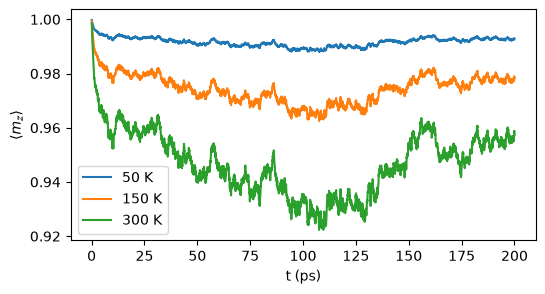

In [3]:
times = np.arange(1, n_steps + 1) * 5.0e-14
fig, ax = plt.subplots(figsize=(6, 3))
for T, mz in traces.items():
    ax.plot(times * 1e12, mz, label=f'{T:.0f} K')
ax.set_xlabel('t (ps)')
ax.set_ylabel('$\\langle m_z \\rangle$')
ax.legend()
plt.show()